<a href="https://colab.research.google.com/github/ASAD001-P/Profit-Driven-Churn-Prediction-System/blob/main/Data_Mining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Profit-Driven Customer Churn Prediction**

In [ ]:
!pip uninstall -y cudf-cu12 cuml-cu12 jax jaxlib
!pip install "numba<0.60" lightgbm shap gradio optuna xgboost category_encoders catboost --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import gradio as gr
import optuna
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, fbeta_score, confusion_matrix
from sklearn.feature_selection import RFE
from category_encoders import TargetEncoder

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(f"✅ Data Loaded: {df.shape}")

✅ Data Loaded: (7043, 21)


In [ ]:
# Phase 3: Cleaning & Advanced Feature Engineering
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Log Transformation
df['TotalCharges'] = np.log1p(df['TotalCharges'])
df['MonthlyCharges'] = np.log1p(df['MonthlyCharges'])

# Service Count (Stickiness Factor)
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Service_Count'] = df[services].apply(lambda x: x.map(lambda s: 0 if 'No' in s else 1)).sum(axis=1)

# Risk Interaction (Contract + Payment)
df['Contract_Payment'] = df['Contract'] + "_" + df['PaymentMethod']

# Tenure Cohorts
df['Tenure_Cohort'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 60, 72, 100],
    labels=['0-1Year', '1-2Years', '2-4Years', '4-5Years', '5-6Years', '6+Years']
)

# Ratios
df['Tenure_MonthlyCharges_Ratio'] = df['tenure'] / (df['MonthlyCharges'] + 1)
df['AvgRevenuePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

print("✅ Advanced Feature Engineering Complete")

✅ Advanced Feature Engineering Complete


In [ ]:
# Phase 4: Train-Test Split & Target Encoding
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Target Encoding
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
encoder = TargetEncoder(cols=cat_cols, smoothing=0.3)
X_train = encoder.fit_transform(X_train_raw, y_train)
X_test = encoder.transform(X_test_raw)

# Calculate Class Weight Ratio
neg_count, pos_count = y_train.value_counts()
scale_pos_weight = neg_count / pos_count
print(f"✅ Calculated Class Weight Ratio: {scale_pos_weight:.2f}")

✅ Calculated Class Weight Ratio: 2.77


In [ ]:
# Phase 5: Optuna Tuning (With CV)
def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 900, 1600),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 32, 128),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 70),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight + 0.5),
        'random_state': 42
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    X_train_cv = X_train.reset_index(drop=True)
    y_train_cv = y_train.reset_index(drop=True)

    for tr_idx, val_idx in cv.split(X_train_cv, y_train_cv):
        X_tr, X_val = X_train_cv.iloc[tr_idx], X_train_cv.iloc[val_idx]
        y_tr, y_val = y_train_cv.iloc[tr_idx], y_train_cv.iloc[val_idx]
        model = lgb.LGBMClassifier(**param)
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("Starting Optuna Optimization (with CV)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("✅ Best Hyperparameters:", study.best_params)

[I 2025-12-19 21:51:09,959] A new study created in memory with name: no-name-148e2029-ea3a-4fb6-872d-599d17581a0d


Starting Optuna Optimization (with CV)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-19 21:51:20,286] Trial 0 finished with value: 0.8360210085043915 and parameters: {'n_estimators': 1586, 'learning_rate': 0.030203308207265595, 'num_leaves': 46, 'max_depth': 6, 'min_child_samples': 67, 'subsample': 0.7378624500807217, 'colsample_bytree': 0.6518057367760629, 'reg_alpha': 3.1103856229125273, 'reg_lambda': 5.836354324561639, 'scale_pos_weight': 1.4213138332113135}. Best is trial 0 with value: 0.8360210085043915.
[I 2025-12-19 21:51:35,385] Trial 1 finished with value: 0.8288815360606115 and parameters: {'n_estimators': 1141, 'learning_rate': 0.02346098384024529, 'num_leaves': 83, 'max_depth': 10, 'min_child_samples': 50, 'subsample': 0.8725785804452579, 'colsample_bytree': 0.6693345173617977, 'reg_alpha': 1.7216301581768292, 'reg_lambda': 5.599907800419283, 'scale_pos_weight': 3.248077698939447}. Best is trial 0 with value: 0.8360210085043915.
[I 2025-12-19 21:51:40,713] Trial 2 finished with value: 0.8435421399684243 and parameters: {'n_estimators': 1302, 'lea

In [ ]:
# Phase 6: RFE & Ensemble
print("Applying Recursive Feature Elimination (RFE)...")
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=0.85)
rfe.fit(X_train, y_train)

selected_cols = X_train.columns[rfe.get_support()]
X_train_sel = X_train[selected_cols]
X_test_sel = X_test[selected_cols]
print(f"✅ Features reduced to {X_train_sel.shape[1]}: {list(selected_cols)}")

best_params = study.best_params
best_params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1})

# Define Base Learners
clf_lgb = lgb.LGBMClassifier(**best_params)

clf_xgb = xgb.XGBClassifier(
    n_estimators=1200, learning_rate=0.02, max_depth=6,
    min_child_weight=3, gamma=0.2, scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42
)

clf_cat = CatBoostClassifier(
    verbose=0, n_estimators=1200, learning_rate=0.03, depth=6,
    l2_leaf_reg=5, scale_pos_weight=scale_pos_weight, random_state=42
)

clf_rf = RandomForestClassifier(
    n_estimators=400, max_depth=10, min_samples_leaf=4,
    class_weight='balanced', random_state=42
)

# --- REVERTED TO VOTING CLASSIFIER (Higher Stability/Accuracy) ---
print("Training Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[('lgb', clf_lgb), ('xgb', clf_xgb), ('cat', clf_cat), ('rf', clf_rf)],
    voting='soft',
    weights=[1.2, 1.2, 1.4, 0.6]
)

ensemble.fit(X_train_sel, y_train)

Applying Recursive Feature Elimination (RFE)...
✅ Features reduced to 20: ['gender', 'SeniorCitizen', 'Partner', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Contract_Payment', 'Tenure_Cohort', 'Tenure_MonthlyCharges_Ratio', 'AvgRevenuePerMonth']
Training Voting Ensemble...


VotingClassifier(estimators=[('lgb',
                              LGBMClassifier(colsample_bytree=0.8986467104392646,
                                             learning_rate=0.04593098720273005,
                                             max_depth=10, metric='auc',
                                             min_child_samples=30,
                                             n_estimators=1576, num_leaves=123,
                                             objective='binary',
                                             reg_alpha=9.510420681426949,
                                             reg_lambda=0.9260233298423054,
                                             scale_pos_weight=1.0492982472566177,
                                             subsample=0.8335177930212304,
                                             verbosi...
                                            max_leaves=None, min_child_weight=3,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7f361683ba70>),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     min_samples_leaf=4,
                                                     n_estimators=400,
                                                     random_state=42))],
                 voting='soft', weights=[1.2, 1.2, 1.4, 0.6])

In [ ]:
# Phase 7: Prediction & Threshold Optimization
y_prob = ensemble.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1_threshold = thresholds[np.argmax([f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds])]
best_prec_threshold = thresholds[np.argmax([fbeta_score(y_test, (y_prob >= t).astype(int), beta=0.5) for t in thresholds])]
best_recall_threshold = thresholds[np.argmax([fbeta_score(y_test, (y_prob >= t).astype(int), beta=2.0) for t in thresholds])]

print(f"\n✅ Best Balanced Threshold (F1): {best_f1_threshold:.2f}")
print(f"✅ Best Precision Threshold (F0.5): {best_prec_threshold:.2f}")

# Final Evaluation
y_pred_final = (y_prob >= best_f1_threshold).astype(int)

print("\n🏆 Ensemble Accuracy:", accuracy_score(y_test, y_pred_final))
print("🏆 Ensemble ROC-AUC :", roc_auc_score(y_test, y_prob))
print("\n--- Classification Report (Balanced Threshold) ---")
print(classification_report(y_test, y_pred_final))


✅ Best Balanced Threshold (F1): 0.46
✅ Best Precision Threshold (F0.5): 0.71

🏆 Ensemble Accuracy: 0.772888573456352
🏆 Ensemble ROC-AUC : 0.8416208116975379

--- Classification Report (Balanced Threshold) ---
              precision    recall  f1-score   support

           0       0.89      0.78      0.84      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



✅ Confusion Matrix saved as 'confusion_matrix.png'

Generating SHAP Feature Importance...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


✅ SHAP Summary saved as 'shap_summary.png'
✅ Model, Encoder, RFE, and Thresholds Saved!


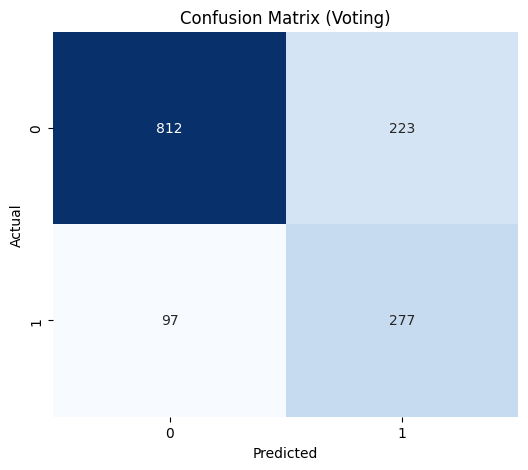

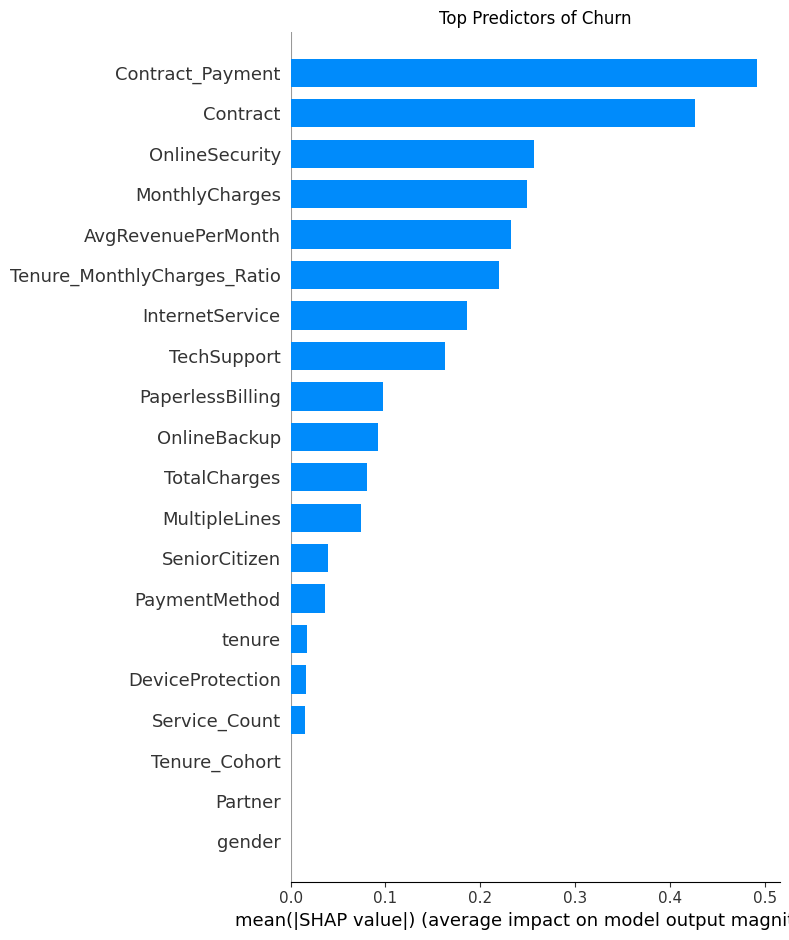

In [ ]:
# Phase 8: Explainability & Saving
# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Voting)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
print("✅ Confusion Matrix saved as 'confusion_matrix.png'")

# 2. SHAP
print("\nGenerating SHAP Feature Importance...")
explainer_model = ensemble.estimators_[0]
explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X_test_sel)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type="bar", show=False)
plt.title("Top Predictors of Churn")
plt.tight_layout()
plt.savefig("shap_summary.png")
print("✅ SHAP Summary saved as 'shap_summary.png'")

# 3. Save Everything (Including Thresholds)
joblib.dump(ensemble, "churn_model_ensemble.pkl")
joblib.dump(encoder, "churn_encoder.pkl")
joblib.dump(rfe, "churn_rfe.pkl")
joblib.dump({
    "best_f1": best_f1_threshold,
    "best_prec": best_prec_threshold,
    "best_recall": best_recall_threshold
}, "churn_thresholds.pkl")

print("✅ Model, Encoder, RFE, and Thresholds Saved!")

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib
# Force non-interactive backend to prevent crashes in web apps
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import uuid
from io import BytesIO
from PIL import Image

In [ ]:
# --- 1. Load Resources ---
try:
    model = joblib.load("churn_model_ensemble.pkl")
    encoder = joblib.load("churn_encoder.pkl")
    rfe = joblib.load("churn_rfe.pkl")
    thresholds = joblib.load("churn_thresholds.pkl")
    print("✅ Models and Thresholds loaded successfully.")

    # Round to 2 decimals immediately for UI cleanliness
    DEFAULT_THRESH = round(float(thresholds.get('best_f1', 0.47)), 2)
    PREC_THRESH = float(thresholds.get('best_prec', 0.71))

except FileNotFoundError:
    print("⚠️ Model files not found. Please run the training script first.")
    model, encoder, rfe, thresholds = None, None, None, {}
    DEFAULT_THRESH = 0.5

# Load raw data for column reference and demo
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_raw = pd.read_csv(url)

CSV_FILE = "new_customers.csv"
# Columns for storage (Raw Data Schema)
CSV_COLUMNS = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'
]

# Columns strictly for Training/Prediction (Must match X_train order exactly)
TRAIN_FEATURES = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Contract_Payment',
    'Tenure_Cohort', 'Tenure_MonthlyCharges_Ratio', 'AvgRevenuePerMonth'
]

# Pre-process raw data
def preprocess_raw_data(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
    if 'Churn' in df.columns and df['Churn'].dtype == 'object':
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    return df

# Select 50 random customers
demo_data = preprocess_raw_data(df_raw).sample(50, random_state=42)
demo_data = demo_data[CSV_COLUMNS]

if not os.path.exists(CSV_FILE):
    dummy = preprocess_raw_data(df_raw).sample(5, random_state=123)
    dummy['customerID'] = dummy['customerID'].apply(lambda x: f"AUTO-{x}")
    dummy = dummy[CSV_COLUMNS]
    dummy.to_csv(CSV_FILE, index=False)

✅ Models and Thresholds loaded successfully.


In [ ]:
# --- 2. Feature Engineering ---
def process_single_customer(data_dict):
    df_input = pd.DataFrame([data_dict])

    # 1. Drop metadata cols
    cols_to_drop = ['customerID', 'Churn']
    df_input = df_input.drop([c for c in cols_to_drop if c in df_input.columns], axis=1)

    # 2. Basic Transformations
    df_input['TotalCharges'] = np.log1p(df_input['TotalCharges'])
    df_input['MonthlyCharges'] = np.log1p(df_input['MonthlyCharges'])

    # 3. Handle missing cols (defaults)
    services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for s in services:
        if s not in df_input.columns: df_input[s] = 'No'

    # 4. Feature Engineering
    df_input['Service_Count'] = df_input[services].apply(lambda x: x.map(lambda s: 0 if 'No' in s else 1)).sum(axis=1)
    df_input['Contract_Payment'] = df_input['Contract'] + "_" + df_input['PaymentMethod']

    df_input['Tenure_Cohort'] = pd.cut(
        df_input['tenure'],
        bins=[-1, 12, 24, 48, 60, 72, 100],
        labels=['0-1Year', '1-2Years', '2-4Years', '4-5Years', '5-6Years', '6+Years']
    )

    df_input['Tenure_MonthlyCharges_Ratio'] = df_input['tenure'] / (df_input['MonthlyCharges'] + 1)
    df_input['AvgRevenuePerMonth'] = df_input['TotalCharges'] / (df_input['tenure'] + 1)

    # --- CRITICAL FIX: Reorder columns to match training order EXACTLY ---
    # This ensures RFE boolean mask applies to the correct columns
    df_input = df_input[TRAIN_FEATURES]

    # 5. Encoding
    df_encoded = encoder.transform(df_input)

    # 6. RFE Selection
    if rfe is not None:
        support_mask = rfe.get_support()
        df_final = df_encoded.iloc[:, support_mask]
    else:
        df_final = df_encoded

    return df_final

In [ ]:
# --- 3. App Functions ---

def predict_new_customer(tenure, monthly, total, contract, payment, internet, tech, security, manual_id):
    if model is None: return "Model not loaded", None

    try:
        # Use manual ID if provided, otherwise auto-generate
        if manual_id and manual_id.strip():
            new_id = manual_id.strip()
        else:
            new_id = f"NEW-{str(uuid.uuid4())[:8]}"

        input_data = {
            'customerID': new_id, 'tenure': tenure, 'MonthlyCharges': monthly, 'TotalCharges': total,
            'Contract': contract, 'PaymentMethod': payment, 'InternetService': internet,
            'TechSupport': tech, 'OnlineSecurity': security,
            'PhoneService': 'Yes', 'MultipleLines': 'No', 'OnlineBackup': 'No',
            'DeviceProtection': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No',
            'PaperlessBilling': 'Yes', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'gender': 'Male',
            'Churn': 0
        }

        # Save to CSV
        save_df = pd.DataFrame([input_data])[CSV_COLUMNS]
        save_df.to_csv(CSV_FILE, mode='a', header=not os.path.exists(CSV_FILE), index=False)

        # Predict
        X = process_single_customer(input_data)
        prob = model.predict_proba(X)[0, 1]

        # Plot SHAP
        explainer = shap.TreeExplainer(model.estimators_[0])
        shap_values = explainer.shap_values(X)

        if isinstance(shap_values, list):
            vals = shap_values[1][0]
        elif len(shap_values.shape) == 3:
            vals = shap_values[0, :, 1]
        else:
            vals = shap_values[0]

        feat_imp = pd.DataFrame({'Feature': X.columns, 'SHAP': vals})
        feat_imp['Abs'] = feat_imp['SHAP'].abs()
        feat_imp = feat_imp.sort_values('Abs', ascending=False).head(5).sort_values('Abs', ascending=True)

        plt.figure(figsize=(8, 4))
        colors = ['red' if x > 0 else 'blue' for x in feat_imp['SHAP']]
        plt.barh(feat_imp['Feature'], feat_imp['SHAP'], color=colors)
        plt.xlabel("Impact on Churn Risk")
        plt.title(f"Top 5 Drivers (Risk: {prob:.1%})")
        plt.tight_layout()

        buf = BytesIO()
        plt.savefig(buf, format="png")
        plt.close()
        buf.seek(0)
        img_output = Image.open(buf)

        return f"Saved ID: {new_id}\nChurn Probability: {prob:.1%}", img_output

    except Exception as e:
        print(f"Error: {e}")
        return f"Error calculating: {str(e)}", None

def update_portfolio(threshold, cltv, retention_cost, _):
    if model is None: return pd.DataFrame(), "Model not loaded"

    df_view = demo_data.copy()
    if os.path.exists(CSV_FILE):
        try:
            df_new = pd.read_csv(CSV_FILE)[CSV_COLUMNS]
            df_view = pd.concat([df_view, df_new], ignore_index=True)
        except: pass

    # Process Portfolio
    temp = df_view.copy()

    # --- Feature Engineering (Batch) ---
    cols_to_drop = ['customerID', 'Churn']
    # Drop IDs first
    temp_feats = temp.drop([c for c in cols_to_drop if c in temp.columns], axis=1)

    temp_feats['TotalCharges'] = np.log1p(temp_feats['TotalCharges'])
    temp_feats['MonthlyCharges'] = np.log1p(temp_feats['MonthlyCharges'])

    services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for s in services:
        if s not in temp_feats.columns: temp_feats[s] = 'No'

    temp_feats['Service_Count'] = temp_feats[services].apply(lambda x: x.map(lambda s: 0 if 'No' in s else 1)).sum(axis=1)
    temp_feats['Contract_Payment'] = temp_feats['Contract'] + "_" + temp_feats['PaymentMethod']
    temp_feats['Tenure_Cohort'] = pd.cut(temp_feats['tenure'], bins=[-1, 12, 24, 48, 60, 72, 100], labels=['0-1Year', '1-2Years', '2-4Years', '4-5Years', '5-6Years', '6+Years'])
    temp_feats['Tenure_MonthlyCharges_Ratio'] = temp_feats['tenure'] / (temp_feats['MonthlyCharges'] + 1)
    temp_feats['AvgRevenuePerMonth'] = temp_feats['TotalCharges'] / (temp_feats['tenure'] + 1)

    # --- CRITICAL FIX: Reorder columns to match training order EXACTLY ---
    temp_feats = temp_feats[TRAIN_FEATURES]

    # Encode & Select
    X = encoder.transform(temp_feats)
    if rfe is not None:
        support_mask = rfe.get_support()
        X = X.iloc[:, support_mask]

    probs = model.predict_proba(X)[:, 1]

    df_view['Churn Probability'] = np.round(probs, 2)
    df_view['Predicted Churn'] = (probs >= threshold).astype(str)
    df_view['Predicted Churn'] = df_view['Predicted Churn'].map({'True': 'Yes', 'False': 'No'})

    tp = np.sum((probs >= threshold) & (df_view['Churn'] == 1))
    flagged = np.sum(probs >= threshold)
    profit = (tp * cltv) - (flagged * retention_cost)

    # --- ADDED customerID to display columns ---
    return df_view[['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'Churn Probability', 'Predicted Churn']], f"💰 Profit: ${profit:,.2f}\n✅ Saved: {tp}\n📉 Offers: {flagged}"

In [ ]:

# --- 4. UI ---
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 📊 PDCCP Dashboard")
    state = gr.State(demo_data)

    with gr.Tabs():
        with gr.Tab("📝 New Customer"):
            with gr.Row():
                with gr.Column():
                    # Added Manual ID field (Optional)
                    in_id = gr.Textbox(label="Customer ID (Optional)", placeholder="Leave blank for auto-generated ID")

                    t = gr.Slider(0, 72, value=12, label="Tenure")
                    m = gr.Number(value=70, label="Monthly Charges")
                    tot = gr.Number(value=1500, label="Total Charges")
                    c = gr.Dropdown(['Month-to-month', 'One year', 'Two year'], value='Month-to-month', label="Contract")
                    p = gr.Dropdown(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], value='Electronic check', label="Payment")
                    i = gr.Dropdown(['DSL', 'Fiber optic', 'No'], value='Fiber optic', label="Internet")
                    ts = gr.Dropdown(['Yes', 'No', 'No internet service'], value='No', label="Tech Support")
                    os_ = gr.Dropdown(['Yes', 'No', 'No internet service'], value='No', label="Online Security")
                    btn = gr.Button("Predict", variant="primary")
                with gr.Column():
                    # Increased lines for bigger output box
                    out_txt = gr.Textbox(label="Result", lines=5)
                    out_img = gr.Image(label="SHAP Analysis", type="pil")
            btn.click(predict_new_customer, inputs=[t, m, tot, c, p, i, ts, os_, in_id], outputs=[out_txt, out_img])

        with gr.Tab("📈 Portfolio Manager"):
            with gr.Row():
                with gr.Column(scale=1):
                    # Formatted to 2 decimal places
                    th = gr.Slider(0.0, 1.0, value=DEFAULT_THRESH, step=0.01, label=f"Threshold (Optimum: {DEFAULT_THRESH:.2f})")
                    cltv = gr.Number(value=1000, label="CLTV ($)")
                    cost = gr.Number(value=100, label="Offer Cost ($)")
                    recalc = gr.Button("Re-Evaluate", variant="primary")
                    # Updated lines to 5 for better visibility
                    stats = gr.Textbox(label="Impact", lines=5)
                with gr.Column(scale=2):
                    tbl = gr.DataFrame()

            app.load(update_portfolio, inputs=[th, cltv, cost, state], outputs=[tbl, stats])
            recalc.click(update_portfolio, inputs=[th, cltv, cost, state], outputs=[tbl, stats])

app.launch(share=True)

/tmp/ipython-input-2462951868.py:2: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6dfc7581ffa83abe4e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
